# 反欺诈风险评分分析 (朴素版)

不依赖外部模块，直接在 Notebook 内读取 CSV、提取特征、加权打分、排序、高中低风险打标。

In [1]:
import pandas as pd
import numpy as np

# ── 1. 读取 CSV ──────────────────────────────────────────
csv_path = "../data/behavior_logs.csv"
df_raw = pd.read_csv(csv_path)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], utc=True)
has_amount = "amount" in df_raw.columns
total_users = df_raw["user_id"].nunique()
all_users = sorted(df_raw["user_id"].unique())

print(f"数据行数: {len(df_raw)}, 用户数: {total_users}")

数据行数: 170, 用户数: 14


In [2]:
# ── 2. 逐用户提取 5 个特征 ──────────────────────────────

# 2.1 设备复用率 (device_reuse_ratio)
device_user_counts = df_raw.groupby("device_id")["user_id"].nunique()
user_devices = df_raw.groupby("user_id")["device_id"].apply(set)
device_reuse = {}
for user in all_users:
    devices = user_devices.get(user, set())
    max_shared = max((device_user_counts.get(d, 0) for d in devices), default=0)
    device_reuse[user] = max_shared / total_users

# 2.2 IP 变更频率 (ip_change_freq)
total_ips = df_raw["ip_address"].nunique()
user_ip_counts = df_raw.groupby("user_id")["ip_address"].nunique()
ip_change = {}
for user in all_users:
    ip_change[user] = user_ip_counts.get(user, 0) / total_ips if total_ips > 0 else 0.0

# 2.3 交易频率 (tx_freq)
tx_df = df_raw[df_raw["event_type"] == "transaction"]
user_tx_counts = tx_df.groupby("user_id").size()
tx_freq = {u: float(user_tx_counts.get(u, 0)) for u in all_users}

# 2.4 登录失败率 (login_fail_ratio)
login_mask = df_raw["event_type"].isin(["login", "login_fail"])
login_df = df_raw[login_mask]
login_fail_counts = login_df[login_df["event_type"] == "login_fail"].groupby("user_id").size()
total_login_counts = login_df.groupby("user_id").size()
login_fail = {}
for user in all_users:
    fails = login_fail_counts.get(user, 0)
    total = total_login_counts.get(user, 0)
    login_fail[user] = (fails / total) if total > 0 else 0.0

# 2.5 金额异常分数 (amount_anomaly_score) — 基于 MAD 稳健 Z-score
amount_anomaly = {u: 0.0 for u in all_users}
if has_amount:
    tx_amount_mask = (df_raw["event_type"] == "transaction") & df_raw["amount"].notna()
    tx_amount_df = df_raw[tx_amount_mask]
    if not tx_amount_df.empty and len(tx_amount_df) >= 2:
        amounts = tx_amount_df["amount"].astype(float)
        median_val = amounts.median()
        mad_val = np.median(np.abs(amounts - median_val)) * 1.4826
        if mad_val > 0 and not pd.isna(mad_val):
            robust_z = np.abs((amounts - median_val) / mad_val)
            anomaly_arr = np.minimum(1.0, robust_z / 3.0)
            tx_amount_df = tx_amount_df.copy()
            tx_amount_df["_anomaly"] = anomaly_arr.values
            user_anomaly_avg = tx_amount_df.groupby("user_id")["_anomaly"].mean()
            for user in all_users:
                if user in user_anomaly_avg.index:
                    amount_anomaly[user] = float(user_anomaly_avg[user])

print("特征提取完成")

特征提取完成


In [3]:
# ── 3. 加权求和 + 8 条规则增强 ───────────────────────────

weights = {
    "device_reuse_ratio": 0.25,
    "ip_change_freq": 0.20,
    "tx_freq": 0.20,
    "login_fail_ratio": 0.15,
    "amount_anomaly_score": 0.20,
}

rows = []
for user in all_users:
    dr = device_reuse[user]
    ip = ip_change[user]
    tx = tx_freq[user]
    lf = login_fail[user]
    aa = amount_anomaly[user]

    # 加权求和（tx_freq 归一化: min(1.0, tx_freq / 100)）
    score = (
        weights["device_reuse_ratio"] * dr
        + weights["ip_change_freq"] * ip
        + weights["tx_freq"] * min(1.0, tx / 100.0)
        + weights["login_fail_ratio"] * lf
        + weights["amount_anomaly_score"] * aa
    ) * 100.0

    # 8 条规则增强 + 记录触发规则
    boost = 0.0
    rules = []
    if dr > 0.9 and tx > 50:
        boost += 10.0; rules.append("R1")
    if ip > 0.8 and lf > 0.5:
        boost += 10.0; rules.append("R2")
    if aa > 0.7:
        boost += 15.0; rules.append("R3")
    if lf > 0.7:
        boost += 20.0; rules.append("R4")
    if dr > 0.2:
        boost += 19.0; rules.append("R5")
    if ip > 0.1 and aa > 0.3:
        boost += 15.0; rules.append("R6")
    if dr > 0.15 and lf > 0.3:
        boost += 15.0; rules.append("R7")
    if tx > 10 and aa > 0.3:
        boost += 15.0; rules.append("R8")

    score += boost
    score = max(0.0, min(100.0, score))  # 钳制到 0~100

    # 风险等级打标
    if score <= 30.0:
        level = "LOW"
    elif score <= 70.0:
        level = "MEDIUM"
    else:
        level = "HIGH"

    rows.append({
        "用户": user,
        "评分": round(score, 2),
        "等级": level,
        "触发规则": ", ".join(rules) if rules else "-",
        "设备复用": round(dr, 3),
        "IP变更": round(ip, 3),
        "交易频率": round(tx, 1),
        "登录失败率": round(lf, 3),
        "金额异常": round(aa, 3),
    })

df = pd.DataFrame(rows)

# ── 4. 按评分降序排序 ────────────────────────────────────
df = df.sort_values("评分", ascending=False).reset_index(drop=True)
df

,用户,评分,等级,触发规则,设备复用,IP变更,交易频率,登录失败率,金额异常
0,u_1007,69.86,MEDIUM,"R3, R6",0.143,0.235,6.0,0.692,1.000
1,u_1006,69.41,MEDIUM,"R3, R6",0.143,0.235,8.0,0.636,0.999
2,u_1013,54.61,MEDIUM,"R3, R6",0.071,0.118,3.0,0.333,0.743
3,u_1011,49.55,MEDIUM,"R5, R7",0.214,0.059,2.0,0.400,0.131
4,u_1008,38.37,MEDIUM,R3,0.071,0.029,5.0,0.000,1.000
5,u_1009,35.23,MEDIUM,R4,0.071,0.059,0.0,0.818,0.000
6,u_1010,31.98,MEDIUM,R5,0.214,0.059,3.0,0.250,0.105
7,u_1012,31.28,MEDIUM,R5,0.214,0.059,3.0,0.250,0.070
8,u_1001,13.45,LOW,-,0.143,0.029,5.0,0.250,0.227
9,u_1003,10.20,LOW,-,0.143,0.029,4.0,0.222,0.095


In [4]:
# ── 5. 带颜色高亮的表格 — 按风险标准标注 ────────────────────
def style_table(df):
    # 等级列颜色
    def color_level(val):
        if val == "HIGH":
            return "background-color: #ff4444; color: white; font-weight: bold"
        elif val == "MEDIUM":
            return "background-color: #4da6ff; color: white; font-weight: bold"
        else:
            return "background-color: #28a745; color: white"

    # 触发规则列颜色
    def color_rules(val):
        if val == "-":
            return ""
        n = len(val.split(", "))
        if n >= 4:
            return "background-color: #ff6666; color: white; font-weight: bold"
        elif n >= 2:
            return "background-color: #ffcc66; font-weight: bold"
        else:
            return "background-color: #ffe0b2"

    return df.style\
        .applymap(color_level, subset=["等级"])\
        .applymap(color_rules, subset=["触发规则"])\
        .background_gradient(subset=["设备复用", "IP变更", "登录失败率", "金额异常"],
                           cmap="YlOrRd", vmin=0, vmax=1)\
        .format({"评分": "{:.2f}"})\
        .bar(subset=["评分"], color="#4da6ff", vmin=0, vmax=100)

style_table(df)

C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\238526087.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_level, subset=["等级"])\
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\238526087.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_rules, subset=["触发规则"])\


,用户,评分,等级,触发规则,设备复用,IP变更,交易频率,登录失败率,金额异常
0,u_1007,69.86,MEDIUM,"R3, R6",0.143000,0.235000,6.000000,0.692000,1.000000
1,u_1006,69.41,MEDIUM,"R3, R6",0.143000,0.235000,8.000000,0.636000,0.999000
2,u_1013,54.61,MEDIUM,"R3, R6",0.071000,0.118000,3.000000,0.333000,0.743000
3,u_1011,49.55,MEDIUM,"R5, R7",0.214000,0.059000,2.000000,0.400000,0.131000
4,u_1008,38.37,MEDIUM,R3,0.071000,0.029000,5.000000,0.000000,1.000000
5,u_1009,35.23,MEDIUM,R4,0.071000,0.059000,0.000000,0.818000,0.000000
6,u_1010,31.98,MEDIUM,R5,0.214000,0.059000,3.000000,0.250000,0.105000
7,u_1012,31.28,MEDIUM,R5,0.214000,0.059000,3.000000,0.250000,0.070000
8,u_1001,13.45,LOW,-,0.143000,0.029000,5.000000,0.250000,0.227000
9,u_1003,10.20,LOW,-,0.143000,0.029000,4.000000,0.222000,0.095000


## 统计摘要

In [5]:
print(f"总用户数: {len(df)}")
print(f"低风险 (LOW): {len(df[df['等级']=='LOW'])} 人")
print(f"中风险 (MEDIUM): {len(df[df['等级']=='MEDIUM'])} 人")
print(f"高风险 (HIGH): {len(df[df['等级']=='HIGH'])} 人")
print(f"平均评分: {df['评分'].mean():.1f}")
print(f"最高评分: {df['评分'].max():.1f} ({df.loc[df['评分'].idxmax(), '用户']})")
print(f"最低评分: {df['评分'].min():.1f} ({df.loc[df['评分'].idxmin(), '用户']})")

总用户数: 14
低风险 (LOW): 6 人
中风险 (MEDIUM): 8 人
高风险 (HIGH): 0 人
平均评分: 31.2
最高评分: 69.9 (u_1007)
最低评分: 7.7 (u_1014)


## 特征分布

C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 35774 (\N{CJK UNIFIED IDEOGRAPH-8BBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 22791 (\N{CJK UNIFIED IDEOGRAPH-5907}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEO

C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 39069 (\N{CJK UNIFIED IDEOGRAPH-989D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 24322 (\N{CJK UNIFIED IDEOGRAPH-5F02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hzj\AppData\Local\Temp\ipykernel_34036\438919319.py:15: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35774 (\N{CJK UNIFIED IDEOGRAPH-8BBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22791 (\N{CJK UNIFIED IDEOGRAPH-5907}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30331 (\N{CJK UNIFIED IDEOGRAPH-767B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\CodeField\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24405 (\N{CJK UNIFIED IDEOGRAPH-5F55}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

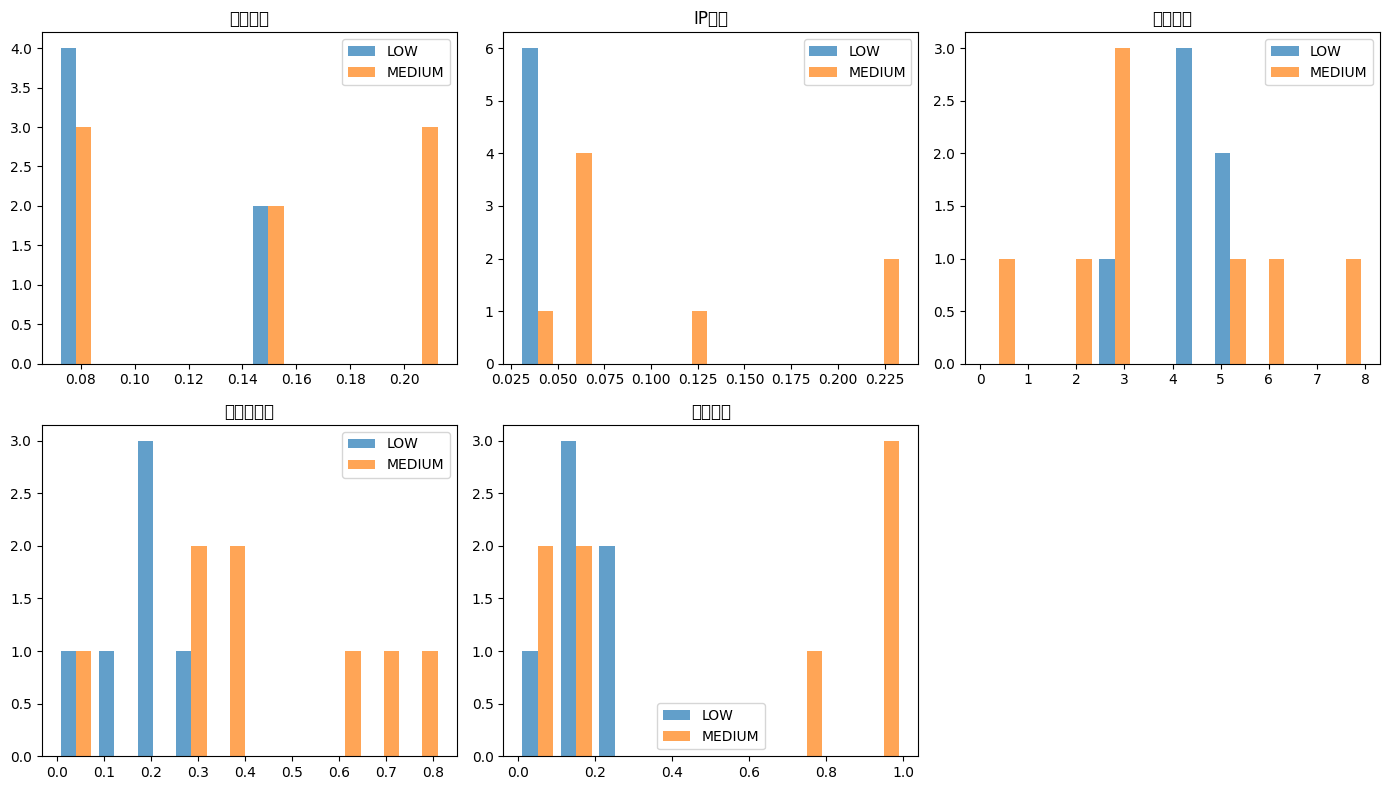

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
features = ["设备复用", "IP变更", "交易频率", "登录失败率", "金额异常"]

for i, feat in enumerate(features):
    low_vals = df[df["等级"] == "LOW"][feat]
    med_vals = df[df["等级"] == "MEDIUM"][feat]
    axes[i].hist([low_vals, med_vals], label=["LOW", "MEDIUM"], bins=10, alpha=0.7)
    axes[i].set_title(feat)
    axes[i].legend()

axes[5].axis("off")
plt.tight_layout()
plt.show()